# Analysis: Hard-Negative Strategies for FinQA Passage Retrieval

This notebook evaluates whether fine-tuning a sentence transformer with **hard negatives** improves intra-document passage retrieval, and compares two negative-mining strategies:

- **BM25 hard negatives** — lexically similar passages from the same document
- **Token-swap negatives** — positives with their most informative word swapped

Each strategy is trained over 3 seeds. Results are reported as mean ± std.

**Outputs:**
1. Main results table (Baseline vs BM25 vs Swap)
2. Bar chart comparing strategies across metrics
3. Per-query category breakdown (improved / regressed / unresolved)
4. Rank-shift distribution (how individual query rankings changed)

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paths to trained model directories (one per seed per strategy)
BM25_SEED_DIRS = [
    Path("data/trained/bm25_seed21"),
    Path("data/trained/bm25_seed42"),
    Path("data/trained/bm25_seed63"),
]
SWAP_SEED_DIRS = [
    Path("data/trained/swap_seed21"),
    Path("data/trained/swap_seed42"),
    Path("data/trained/swap_seed63"),
]

STRATEGIES = {
    "BM25": BM25_SEED_DIRS,
    "Swap": SWAP_SEED_DIRS,
}

## 1. Main results table

Each cell shows the mean across seeds with the standard deviation in parentheses.

In [2]:
METRICS = ["Recall@1", "Recall@3", "Recall@5", "MRR"]


def load_seed_metrics(seed_dirs):
    """Returns a dict: metric_name -> list of values across seeds."""
    metrics = {m: [] for m in METRICS}
    for seed_dir in seed_dirs:
        eval_file = seed_dir / "eval_results.json"
        if not eval_file.exists():
            print(f"Missing: {eval_file}")
            continue
        with open(eval_file, encoding="utf-8") as f:
            results = json.load(f)
        metrics["Recall@1"].append(results["Test"]["Recall@1"])
        metrics["Recall@3"].append(results["Test"]["Recall@3"])
        metrics["Recall@5"].append(results["Test"]["Recall@5"])
        metrics["MRR"].append(results["MRR"])
    return metrics


def format_mean_std(values):
    if not values:
        return "–"
    mean = np.mean(values)
    std = np.std(values, ddof=1) if len(values) > 1 else 0.0
    return f"{mean:.4f} ({std:.4f})"


# Baseline = zero-shot, same for both strategies → take from any seed dir's baseline_ranks
# Computed here from the per-query baseline file of the first available run.
def load_baseline_recall_and_mrr(seed_dirs):
    for seed_dir in seed_dirs:
        baseline_file = seed_dir / "baseline_ranks.json"
        if baseline_file.exists():
            with open(baseline_file, encoding="utf-8") as f:
                ranks = json.load(f)
            ranks = list(ranks.values())
            return {
                "Recall@1": np.mean([1 if r <= 1 else 0 for r in ranks]),
                "Recall@3": np.mean([1 if r <= 3 else 0 for r in ranks]),
                "Recall@5": np.mean([1 if r <= 5 else 0 for r in ranks]),
                "MRR": np.mean([1.0 / r for r in ranks]),
            }
    return None


rows = {}

baseline_metrics = load_baseline_recall_and_mrr(BM25_SEED_DIRS + SWAP_SEED_DIRS)
if baseline_metrics:
    rows["Zero-shot baseline"] = {m: f"{baseline_metrics[m]:.4f}" for m in METRICS}

for name, seed_dirs in STRATEGIES.items():
    seed_metrics = load_seed_metrics(seed_dirs)
    rows[name] = {m: format_mean_std(seed_metrics[m]) for m in METRICS}

results_table = pd.DataFrame(rows).T
results_table

,Recall@1,Recall@3,Recall@5,MRR
Zero-shot baseline,0.7188,0.8639,0.8934,0.8015
BM25,0.7596 (0.0079),0.8919 (0.0129),0.9267 (0.0092),0.8341 (0.0072)
Swap,0.6765 (0.0057),0.8337 (0.0035),0.8972 (0.0086),0.7744 (0.0045)


## 2. Strategy comparison across metrics

Bar chart of mean values with standard deviation as error bars.

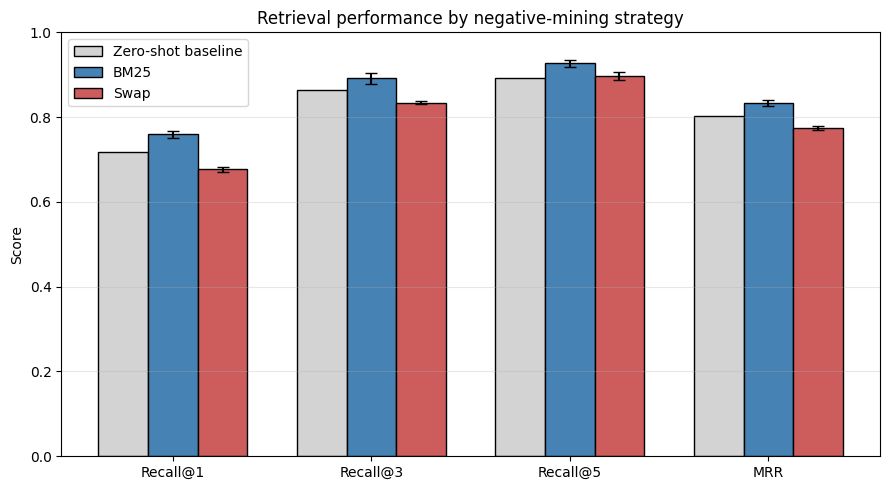

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

x_positions = np.arange(len(METRICS))
bar_width = 0.25

# Baseline bars
if baseline_metrics:
    baseline_values = [baseline_metrics[m] for m in METRICS]
    ax.bar(
        x_positions - bar_width,
        baseline_values,
        bar_width,
        label="Zero-shot baseline",
        color="lightgray",
        edgecolor="black",
    )

# Strategy bars
strategy_colors = {"BM25": "steelblue", "Swap": "indianred"}
offsets = {"BM25": 0.0, "Swap": bar_width}

for name, seed_dirs in STRATEGIES.items():
    seed_metrics = load_seed_metrics(seed_dirs)
    means = [np.mean(seed_metrics[m]) for m in METRICS]
    stds = [np.std(seed_metrics[m], ddof=1) if len(seed_metrics[m]) > 1 else 0.0 for m in METRICS]
    ax.bar(
        x_positions + offsets[name],
        means,
        bar_width,
        yerr=stds,
        label=name,
        color=strategy_colors[name],
        edgecolor="black",
        capsize=4,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(METRICS)
ax.set_ylabel("Score")
ax.set_title("Retrieval performance by negative-mining strategy")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Per-query category breakdown

How does each strategy change retrieval outcomes on individual queries (Recall@5)?

- **already_easy** — recalled by baseline AND by trained model
- **improved** — only recalled after training
- **regressed** — recalled by baseline but lost after training
- **unresolved** — never recalled

Averaged across seeds.

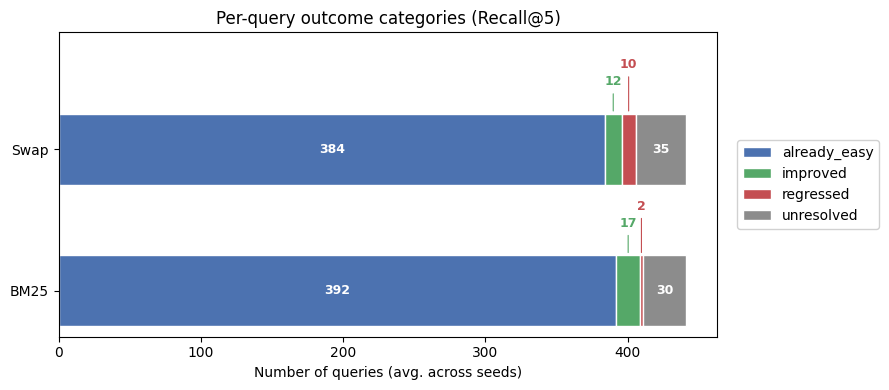

In [13]:
CATEGORIES = ["already_easy", "improved", "regressed", "unresolved"]
CATEGORY_COLORS = {
    "already_easy": "#4c72b0",
    "improved": "#55a868",
    "regressed": "#c44e52",
    "unresolved": "#8c8c8c",
}


def load_category_counts(seed_dirs):
    """Returns average count per category across seeds."""
    sums = Counter()
    n_seeds = 0
    for seed_dir in seed_dirs:
        analysis_file = seed_dir / "query_analysis.json"
        if not analysis_file.exists():
            continue
        with open(analysis_file, encoding="utf-8") as f:
            analysis = json.load(f)
        for cat in CATEGORIES:
            sums[cat] += len(analysis.get(cat, []))
        n_seeds += 1
    if n_seeds == 0:
        return {cat: 0 for cat in CATEGORIES}
    return {cat: sums[cat] / n_seeds for cat in CATEGORIES}


fig, ax = plt.subplots(figsize=(9, 4))

strategy_names = list(STRATEGIES.keys())
y_positions = np.arange(len(strategy_names))

category_counts_per_strategy = {
    name: load_category_counts(seed_dirs)
    for name, seed_dirs in STRATEGIES.items()
}

BAR_HEIGHT = 0.5
LABEL_ABOVE_OFFSETS = {"improved": 0.18, "regressed": 0.30}

left_offsets = np.zeros(len(strategy_names))
for cat in CATEGORIES:
    values = [category_counts_per_strategy[name][cat] for name in strategy_names]
    ax.barh(
        y_positions,
        values,
        height=BAR_HEIGHT,
        left=left_offsets,
        label=cat,
        color=CATEGORY_COLORS[cat],
        edgecolor="white",
    )
    for i, v in enumerate(values):
        if v <= 0:
            continue
        segment_center_x = left_offsets[i] + v / 2
        bar_top_y = y_positions[i] + BAR_HEIGHT / 2

        if cat in LABEL_ABOVE_OFFSETS:
            # Place number above the bar with a thin leader line to the segment.
            # Improved and regressed are staggered vertically to avoid overlap.
            ax.annotate(
                f"{int(round(v))}",
                xy=(segment_center_x, bar_top_y),
                xytext=(segment_center_x, bar_top_y + LABEL_ABOVE_OFFSETS[cat]),
                ha="center", va="bottom",
                fontsize=9, fontweight="bold",
                color=CATEGORY_COLORS[cat],
                arrowprops=dict(arrowstyle="-", color=CATEGORY_COLORS[cat], lw=0.8),
            )
        else:
            # Place number inside the segment
            ax.text(
                segment_center_x,
                y_positions[i],
                f"{int(round(v))}",
                ha="center", va="center",
                color="white", fontsize=9, fontweight="bold",
            )
    left_offsets += np.array(values)

# Give the y-axis some extra room above the top bar for the staggered annotations
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max + 0.5)

ax.set_yticks(y_positions)
ax.set_yticklabels(strategy_names)
ax.set_xlabel("Number of queries (avg. across seeds)")
ax.set_title("Per-query outcome categories (Recall@5)")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    framealpha=0.9,
)

plt.tight_layout()
plt.show()

 ## 4. Rank-shift distribution

For each query, we compute `rank_shift = baseline_rank - trained_rank`.
Positive values mean the model moved the gold passage higher up.
Aggregated across all seeds of one strategy.

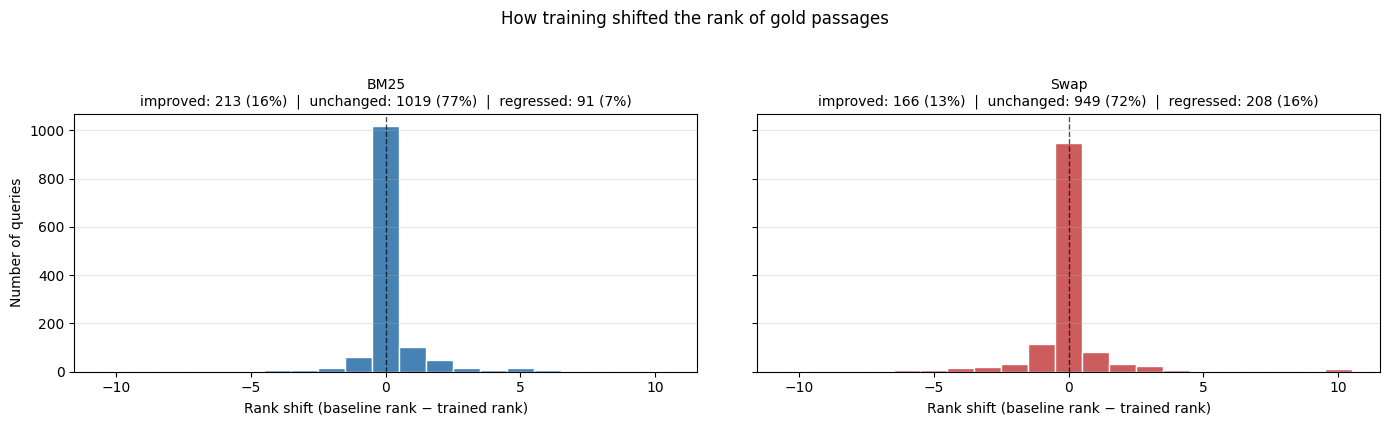

In [8]:
def collect_rank_shifts(seed_dirs):
    """Returns a list of (baseline_rank - trained_rank) values across all seeds."""
    shifts = []
    for seed_dir in seed_dirs:
        analysis_file = seed_dir / "query_analysis.json"
        if not analysis_file.exists():
            continue
        with open(analysis_file, encoding="utf-8") as f:
            analysis = json.load(f)
        baseline_ranks = analysis.get("baseline_best_rank", {})
        trained_ranks = analysis.get("trained_best_rank", {})
        for qid, baseline_rank in baseline_ranks.items():
            if qid in trained_ranks:
                shifts.append(baseline_rank - trained_ranks[qid])
    return shifts


fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

shift_range_clip = 10  # clip extreme outliers to this range for readability

for ax, (name, seed_dirs) in zip(axes, STRATEGIES.items()):
    shifts = collect_rank_shifts(seed_dirs)
    if not shifts:
        ax.set_title(f"{name}: no data")
        continue

    clipped = [max(-shift_range_clip, min(shift_range_clip, s)) for s in shifts]
    bins = np.arange(-shift_range_clip - 0.5, shift_range_clip + 1.5, 1)

    ax.hist(clipped, bins=bins, color=strategy_colors[name], edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)

    improved = sum(1 for s in shifts if s > 0)
    unchanged = sum(1 for s in shifts if s == 0)
    regressed = sum(1 for s in shifts if s < 0)
    total = len(shifts)

    ax.set_title(
        f"{name}\n"
        f"improved: {improved} ({100*improved/total:.0f}%)  |  "
        f"unchanged: {unchanged} ({100*unchanged/total:.0f}%)  |  "
        f"regressed: {regressed} ({100*regressed/total:.0f}%)",
        fontsize=10,
    )
    ax.set_xlabel("Rank shift (baseline rank − trained rank)")
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Number of queries")
fig.suptitle("How training shifted the rank of gold passages", y=1.05)

plt.tight_layout(w_pad=4)
plt.show()